In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot_timeseries import (
    distributions,
    generate_ground_truth,
    sample_parameters,
)

In [2]:
def owens_bozic_model(y, t, params):
    T, E, C, M = y
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params

    C = max(C, 0)
    E = max(E, 0)

    tol = 1e-10

    if T < tol:
        DE = 0
    elif E < T:
        DE = dE * (E / T)**l / (s + (E / T)**l) * T
    else:
        DE = dE * (1 - s / (s + (T/E)**(-l))) * T

    if T < tol:
        DC = 0
    elif C < T:
        DC = dC * (C / T)**l / (s + (C / T)**l) * T
    else:
        DC = dC * (1 - s / (s + (T/C)**(-l))) * T

    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    dE_dt = g - mE * E - jE * np.log((E + C) / K) * (DE**2) / (k + DE**2) * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt = - mC * C - jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    return [dT_dt, dE_dt, dC_dt, dM_dt]

## error models

In [3]:
def add_noise_prop(obs: np.ndarray, prop_sd_factor: float, seed=42) -> np.ndarray:
    np.random.seed(seed)
    return np.clip(
        obs * (1 + prop_sd_factor * np.random.normal(size=obs.size)), 0, None
    )

def add_noise_lognormal(obs: np.ndarray, sd: float, seed=42) -> np.ndarray:
    np.random.seed(seed)
    return obs * np.exp(sd * np.random.normal(size=obs.size))

### seeing how the plots look

In [50]:
def plot_ground_truth_with_noisy_overlays(
    ax, 
    obs_time_ground_truth: list[float], 
    ground_truth: np.ndarray, 
    obs_time_reduced: list[float], 
    noisy_trials: list[np.ndarray], 
    noisy_labels: list[str] = None, 
    ground_truth_label: str = "Ground Truth",
    title: str = "Ground Truth vs Noisy Data Overlays",
    semilogy: bool = False,
):
    """
    Plot a ground truth timeseries with several noisy overlays on a given Axes.

    Parameters:
        ax: Matplotlib Axes object.
        obs_time_ground_truth: 1D array-like of time points for the ground truth.
        ground_truth: 1D array-like of ground truth values.
        obs_time_reduced: 1D array-like of time points for the noisy trials.
        noisy_trials: List of 1D array-like noisy timeseries.
        noisy_labels: Optional list of labels for the noisy trials.
        ground_truth_label: Label for the ground truth timeseries.
        semilogy: If True, produce a semilogy plot with y-values clipped at 0.01.
        custom_labels: Optional dictionary with keys "ground_truth" and "noisy_trials" for custom labels.
    """

    if semilogy:
        ground_truth = np.clip(ground_truth, 0.01, None)
        noisy_trials = [np.clip(trial, 0.01, None) for trial in noisy_trials]
        ax.semilogy(obs_time_ground_truth, ground_truth, label=ground_truth_label, linewidth=2)
    else:
        ax.plot(obs_time_ground_truth, ground_truth, label=ground_truth_label, linewidth=2)

    for i, trial in enumerate(noisy_trials):
        label = noisy_labels[i] if noisy_labels and i < len(noisy_labels) else f"Noisy Trial {i+1}"
        if semilogy:
            ax.semilogy(obs_time_reduced, trial, "o", label=label)
        else:
            ax.plot(obs_time_reduced, trial, "o", label=label)

    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Number of cells")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

In [5]:
pop_param_info = [
    (3.3e-1, 0.6),
    (2.26e-11, 5.1),
    (3.17, 0.6),
    (2.25, 0.01),
    (1.03e4, 1.7),
    (1.56e-2, 0.75),
    (3.46e-1, 0.75),
    (5.21e8, 1.5),
    (8.67e6, 3.0),
    (1.418, 0.013),
    (1.76e-2, 0.76),
    (0.293, 0.01),
    (1.28e-10, 1.35),
    (2.14e-10, 2.6),
    (3.02e-1, 0.17),
    (0.7, 0.01),
    (0.6, 0.01),
    (0.6, 0.01),
    (0.9, 0.01),
]

init_cond_info = [
    (1.58e9, 1.5),
    (4e5, 0.01),
    (6.3e7, 2.0),
    (6.0, 0.2),
]

pop_param_means, pop_param_stds = zip(*pop_param_info)
init_cond_means, init_cond_stds = zip(*init_cond_info)
n_samples = 5

param_lists = sample_parameters(
    pop_param_means,
    [distributions["lognormal"]] * len(pop_param_info),
    pop_param_stds,
    n_samples=n_samples,
)
init_cond_lists = sample_parameters(
    init_cond_means,
    [distributions["lognormal"]] * len(init_cond_info),
    init_cond_stds,
    n_samples,
)

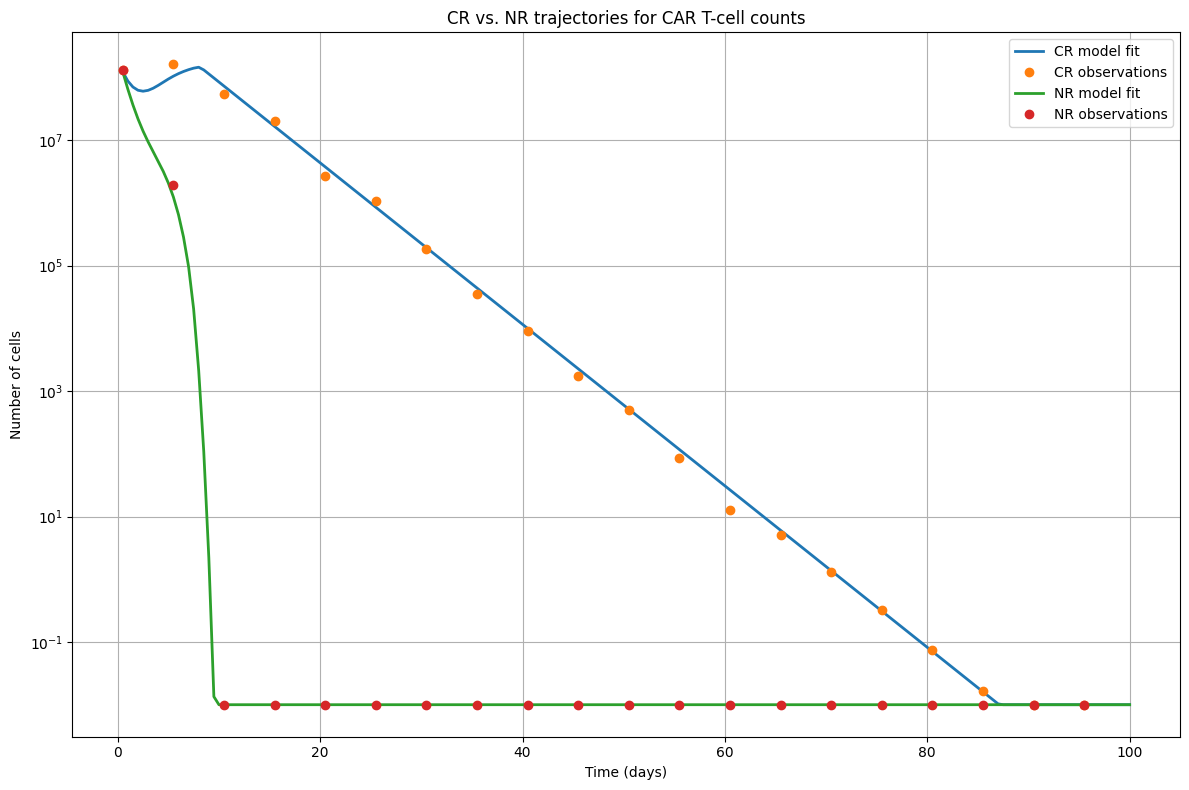

In [53]:
noise_level = 0.25
n_pts_gt = 200
n_pts_obs = 20

fig, axs = plt.subplots(nrows=1, ncols=1)

for idx in [0, 4]:
    obs_times = np.linspace(100 / n_pts_gt, 100, n_pts_gt)
    params = param_lists[idx]
    init_conds = init_cond_lists[1]
    ground_truths = generate_ground_truth(owens_bozic_model, params, init_conds, obs_times)
    ground_truth = ground_truths[2]
    n_noisy_obs = 1
    noisy_obs_lists_prop = [
        add_noise_prop(ground_truth, prop_sd_factor=noise_level, seed=17 * (i + 1))
        for i in range(n_noisy_obs)
    ]
    obs_times_reduced = obs_times[::(n_pts_gt // n_pts_obs)]


    fig.set_figwidth(12)
    fig.set_figheight(8)
    plt.tight_layout()
    plot_ground_truth_with_noisy_overlays(
        axs,
        obs_times,
        ground_truth,
        obs_times_reduced,
        [x[::(n_pts_gt // n_pts_obs)] for x in noisy_obs_lists_prop],
        semilogy=True,
        ground_truth_label=f"{'CR' if idx == 0 else 'NR'} model fit",
        noisy_labels=[f"{'CR' if idx == 0 else 'NR'} observations" for _ in range(n_noisy_obs)],
        title="CR vs. NR trajectories for CAR T-cell counts",
    )

## censoring and generating csvs

[How Monolix handles censored data](https://monolixsuite.slp-software.com/monolix/2024R1/handling-censored-data)